This notebook has been adapted for Google Colab. Before running, please ensure you have uploaded your `train.csv` and `test.csv` files to the Colab environment using the file upload cell below or by mounting Google Drive.

In [ ]:
# Install necessary libraries if not already present in Colab
!pip install transformers datasets evaluate --quiet
!pip install nltk --quiet

# Sentiment Analysis Tool
This notebook compares a classical TF-IDF model with a fine-tuned DistilBERT transformer. Each step is documented so the workflow is reproducible and suitable for an academic project.

## 1. Setup & Imports
We import the libraries used for data handling, visualization, preprocessing, classical machine learning, and transformer fine-tuning. A fixed seed makes comparisons repeatable.

In [ ]:
import os
import re
import random
import time
import html
import warnings
from pathlib import Path

# This notebook trains PyTorch models; force Transformers to skip its optional TensorFlow path.
os.environ['USE_TF'] = '0'
os.environ['TRANSFORMERS_NO_TF'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)

import torch
from datasets import Dataset
import evaluate

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

TRAIN_PATH = 'train.csv'
TEST_PATH = 'test.csv'
TEXT_COLUMN = 'text'  # Set a column name here to override auto-detection.
LABEL_COLUMN = 'sentiment'  # Set a column name here to override auto-detection.
MAX_SAMPLES = 20000
NEGATIVE_MAX = 2
NEUTRAL_VALUE = 3
POSITIVE_MIN = 4
TRANSFORMER_MODEL_NAME = 'distilbert-base-uncased'
TRANSFORMER_EPOCHS = 2 if torch.cuda.is_available() else 1
TRANSFORMER_BATCH_SIZE = 16 if torch.cuda.is_available() else 4
device_name = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device_name}')

Using device: cuda


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding

The training and supplied test CSVs are loaded from configurable paths. The training file is used for exploration and later split into train/validation data, while the test file remains an untouched final holdout. Automatic column detection is a convenience, while explicit validation makes mistakes visible before modeling begins.

Please upload `train.csv` and `test.csv` now. If using Google Drive, uncomment and run the mounting code in the following cell.

In [ ]:
from google.colab import files

# Option 1: Upload files directly (recommended for smaller datasets)
uploaded = files.upload()
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

# Option 2: Mount Google Drive (recommended for larger datasets or persistent storage)
# from google.colab import drive
# drive.mount('/content/drive')
# TRAIN_PATH = '/content/drive/MyDrive/path/to/train.csv' # Update with your path
# TEST_PATH = '/content/drive/MyDrive/path/to/test.csv'   # Update with your path

# For simplicity, if files are not uploaded via `files.upload()`, we assume they are already in the root Colab directory (e.g., drag and dropped).
# If using Option 1, you can comment out these checks or modify `TRAIN_PATH` and `TEST_PATH` above if you need specific file names.
# If using Option 2, uncomment and update `TRAIN_PATH` and `TEST_PATH` in the previous cell.

print('Ensure train.csv and test.csv are available in the current Colab environment.')

Saving train.csv to train (1).csv
Saving test.csv to test (1).csv
User uploaded file "train (1).csv" with length 3390292 bytes
User uploaded file "test (1).csv" with length 299850 bytes
Ensure train.csv and test.csv are available in the current Colab environment.


In [ ]:
train_file = Path(TRAIN_PATH)
test_file = Path(TEST_PATH)
for path in [train_file, test_file]:
    if not path.exists():
        raise FileNotFoundError(f'Dataset file does not exist: {path.resolve()}. Update TRAIN_PATH or TEST_PATH in the first code cell.')
df = pd.read_csv(train_file, encoding='latin-1')
test_raw_df = pd.read_csv(test_file, encoding='latin-1')
if df.empty or test_raw_df.empty:
    raise ValueError('train.csv and test.csv must both contain at least one row.')


def detect_columns(frame):
    object_columns = frame.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
    if not object_columns:
        raise ValueError('No string-like column was found for text. Set TEXT_COLUMN manually.')
    text_scores = {column: frame[column].dropna().astype(str).str.len().mean() for column in object_columns}
    detected_text = max(text_scores, key=text_scores.get)
    candidates = [column for column in frame.columns if column != detected_text]
    categorical = []
    for column in candidates:
        unique_count = frame[column].nunique(dropna=True)
        if 2 <= unique_count <= min(50, max(2, int(len(frame) * 0.2))):
            categorical.append((unique_count, column))
    if not categorical:
        raise ValueError('Could not detect a likely label column. Set LABEL_COLUMN manually.')
    detected_label = min(categorical)[1]
    return detected_text, detected_label


detected_text, detected_label = detect_columns(df)
TEXT_COLUMN = TEXT_COLUMN or detected_text
LABEL_COLUMN = LABEL_COLUMN or detected_label
missing_columns = [column for column in [TEXT_COLUMN, LABEL_COLUMN] if column not in df.columns]
missing_test_columns = [column for column in [TEXT_COLUMN, LABEL_COLUMN] if column not in test_raw_df.columns]
if missing_columns or missing_test_columns:
    raise KeyError(f'Missing train columns: {missing_columns}; missing test columns: {missing_test_columns}. Available train columns: {df.columns.tolist()}')
print(f'Text column: {TEXT_COLUMN}')
print(f'Label column: {LABEL_COLUMN}')
print('Training shape:', df.shape)
print('Test shape:', test_raw_df.shape)
display(df.head())
df.info()

Text column: text
Label column: sentiment
Training shape: (27481, 9)
Test shape: (3534, 8)


,text,selected_text,sentiment,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,NaN,NaN,NaN,NaN,NaN,NaN
1,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,NaN,NaN,NaN,NaN,NaN,NaN
2,my boss is bullying me...,bullying me,negative,NaN,NaN,NaN,NaN,NaN,NaN
3,what interview! leave me alone,leave me alone,negative,NaN,NaN,NaN,NaN,NaN,NaN
4,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   text           27480 non-null  object 
 1   selected_text  27480 non-null  object 
 2   sentiment      27481 non-null  object 
 3   Unnamed: 3     0 non-null      float64
 4   Unnamed: 4     0 non-null      float64
 5   Unnamed: 5     0 non-null      float64
 6   Unnamed: 6     0 non-null      float64
 7   Unnamed: 7     0 non-null      float64
 8   Unnamed: 8     0 non-null      float64
dtypes: float64(6), object(3)
memory usage: 1.9+ MB


The first EDA cell establishes data quality and class balance; this follow-up cell visualizes text length and samples representative rows for qualitative inspection.

Missing values: text         1
sentiment    0
dtype: int64
Duplicate rows: 0
Class counts:
 sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64
Potential imbalance: NO (largest/smallest ratio=1.43)

Samples for class: negative


,text,sentiment,text_length_words
27050,says BAD TRIP! (angry) http://plurk.com/p/wxshi,negative,5
7004,that sounds foreboding...,negative,3
8212,_kat I`ve begged my mum to lt me get them out...,negative,24



Samples for class: neutral


,text,sentiment,text_length_words
4634,i have to go to the doctor... i don`t want to....,neutral,18
8316,Can`t sleep but is happy that the Fugees are k...,neutral,12
12622,Job??????? Not so much.,neutral,4



Samples for class: positive


,text,sentiment,text_length_words
15803,is excited to be visited by her twin and best ...,positive,20
15374,It`s fun to see that glimpse of your life,positive,9
21359,"Wow, it`s so early. Just had the best conversa...",positive,9


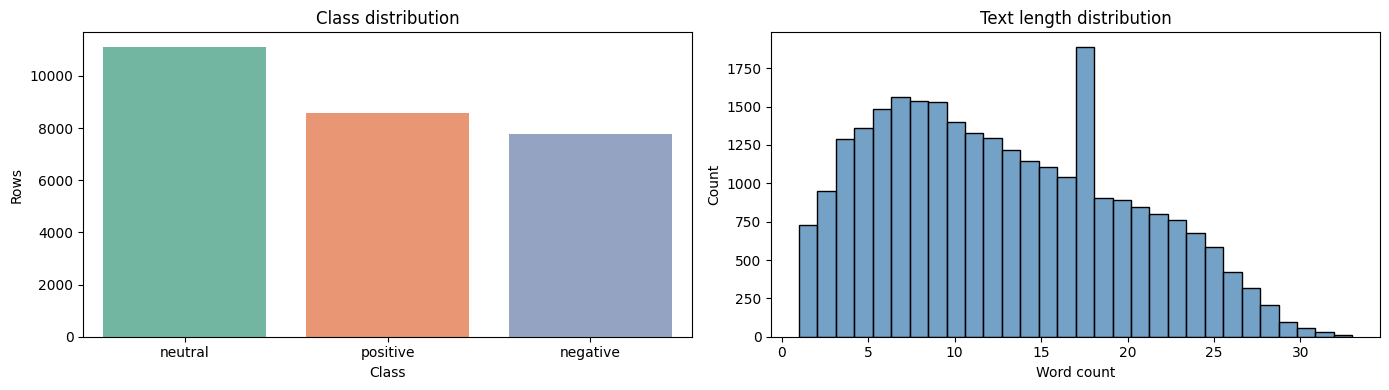

In [ ]:
print('Missing values:', df[[TEXT_COLUMN, LABEL_COLUMN]].isna().sum())
print('Duplicate rows:', df.duplicated().sum())
eda_df = df[[TEXT_COLUMN, LABEL_COLUMN]].copy()
eda_df = eda_df.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN])
eda_df['text_length_words'] = eda_df[TEXT_COLUMN].astype(str).str.split().str.len()
class_counts = eda_df[LABEL_COLUMN].astype(str).value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()
print('Class counts:\n', class_counts)
print('Potential imbalance:', 'YES' if imbalance_ratio >= 1.5 else 'NO', f'(largest/smallest ratio={imbalance_ratio:.2f})')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, ax=axes[0], palette='Set2')
axes[0].set_title('Class distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Rows')
sns.histplot(eda_df['text_length_words'], bins=30, ax=axes[1], color='steelblue')
axes[1].set_title('Text length distribution')
axes[1].set_xlabel('Word count')
plt.tight_layout()

for class_name, group in eda_df.groupby(LABEL_COLUMN):
    print(f'\nSamples for class: {class_name}')
    display(group.sample(n=min(3, len(group)), random_state=SEED))

## 3. Preprocessing
The classical model benefits from normalized tokens. Negation words are retained because removing words such as `not` can reverse the meaning of a sentiment.

In [ ]:
for package in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    try:
        nltk.download(package, quiet=True)
    except Exception as download_error:
        print(f'Could not download NLTK resource {package}: {download_error}')

NEGATION_WORDS = {'no', 'not', 'nor', 'never', 'neither', 'cannot', 'cant', "don't", "isn't", "wasn't", "won't", "wouldn't", "couldn't", "shouldn't", "n't"}
STOP_WORDS = set(stopwords.words('english')) - NEGATION_WORDS
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    text = html.unescape(str(text)).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[@#](\w+)', r'\1', text)
    text = re.sub(r"[^a-zA-Z0-9'\s]|(?<![a-zA-Z])'(?!t\b)", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    normalized = []
    for token in tokens:
        if token in STOP_WORDS or not re.search(r'[a-zA-Z0-9]', token):
            continue
        normalized.append(lemmatizer.lemmatize(token))
    return ' '.join(normalized)


def prepare_text_frame(frame):
    prepared = frame[[TEXT_COLUMN, LABEL_COLUMN]].copy()
    prepared = prepared.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN]).drop_duplicates().reset_index(drop=True)
    prepared['raw_text'] = prepared[TEXT_COLUMN].astype(str).str.replace(r'<[^>]+>', ' ', regex=True).str.replace(r'https?://\S+|www\.\S+', ' ', regex=True).str.strip()
    prepared['clean_text'] = prepared[TEXT_COLUMN].map(clean_text)
    return prepared[prepared['clean_text'].str.len() > 0].reset_index(drop=True)


model_df = prepare_text_frame(df)
test_model_df = prepare_text_frame(test_raw_df)
display(model_df[[TEXT_COLUMN, 'clean_text']].head(8))

,text,clean_text
0,"I`d have responded, if I were going",responded going
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad miss san diego
2,my boss is bullying me...,bos bullying
3,what interview! leave me alone,interview leave alone
4,"Sons of ****, why couldn`t they put them on t...",son put release already bought
5,http://www.dothebouncy.com/smf - some shameles...,shameless plugging best ranger forum earth
6,2am feedings for the baby are fun when he is a...,2am feeding baby fun smile coo
7,Soooo high,soooo high


## 4. Label Encoding & Train/Val/Test Split
Labels are converted into integer IDs for both model families. Numeric ratings are optionally mapped to negative, neutral, and positive classes using the configurable thresholds above.

In [ ]:
def normalize_label(value):
    if pd.api.types.is_number(value):
        numeric_value = float(value)
        if numeric_value <= NEGATIVE_MAX:
            return 'negative'
        if numeric_value >= POSITIVE_MIN:
            return 'positive'
        return 'neutral'
    return str(value).strip().lower()


model_df['normalized_label'] = model_df[LABEL_COLUMN].map(normalize_label)
test_model_df['normalized_label'] = test_model_df[LABEL_COLUMN].map(normalize_label)
label_encoder = LabelEncoder()
model_df['label_id'] = label_encoder.fit_transform(model_df['normalized_label'])
unknown_test_labels = set(test_model_df['normalized_label']) - set(label_encoder.classes_)
if unknown_test_labels:
    raise ValueError(f'Test labels not present in train.csv: {unknown_test_labels}')
test_model_df['label_id'] = label_encoder.transform(test_model_df['normalized_label'])
label_mapping = dict(enumerate(label_encoder.classes_))
print('Label mapping:', label_mapping)

train_df, val_df = train_test_split(model_df, test_size=0.15, random_state=SEED, stratify=model_df['label_id'])
test_df = test_model_df.copy()
print(f'Train: {len(train_df)}, validation: {len(val_df)}, provided test: {len(test_df)}')
class_weight = 'balanced'
train_texts = train_df['clean_text'].tolist()
val_texts = val_df['clean_text'].tolist()
test_texts = test_df['clean_text'].tolist()
train_labels = train_df['label_id'].to_numpy()
val_labels = val_df['label_id'].to_numpy()
test_labels = test_df['label_id'].to_numpy()

Label mapping: {0: 'negative', 1: 'neutral', 2: 'positive'}
Train: 23295, validation: 4112, provided test: 3523


The validation table selects the baseline by macro F1. This next cell evaluates that selected classifier once on the held-out test set and visualizes its errors.

## 5. Baseline Model: TF-IDF + Classical ML
TF-IDF represents word and phrase importance while three complementary classifiers provide a useful, fast baseline comparison. Validation macro F1 is emphasized so minority classes matter.

In [ ]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, min_df=2, sublinear_tf=True)
X_train = vectorizer.fit_transform(train_texts)
X_val = vectorizer.transform(val_texts)
X_test = vectorizer.transform(test_texts)

classifiers = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight=class_weight, random_state=SEED),
    'LinearSVC': LinearSVC(class_weight=class_weight, random_state=SEED),
    'MultinomialNB': MultinomialNB(),
}
baseline_results = []
baseline_models = {}
for name, classifier in classifiers.items():
    start = time.perf_counter()
    classifier.fit(X_train, train_labels)
    predictions = classifier.predict(X_val)
    elapsed = time.perf_counter() - start
    baseline_models[name] = classifier
    baseline_results.append({'model': name, 'accuracy': accuracy_score(val_labels, predictions), 'macro_f1': f1_score(val_labels, predictions, average='macro'), 'training_seconds': elapsed})
baseline_validation = pd.DataFrame(baseline_results).sort_values('macro_f1', ascending=False)
display(baseline_validation)
best_baseline_name = baseline_validation.iloc[0]['model']
best_baseline = baseline_models[best_baseline_name]
print('Selected baseline:', best_baseline_name)

,model,accuracy,macro_f1,training_seconds
0,LogisticRegression,0.692364,0.695721,3.770277
1,LinearSVC,0.674125,0.676937,0.825127
2,MultinomialNB,0.646644,0.641206,0.006905


Selected baseline: LogisticRegression


The three validation scores identify the strongest classical candidate. This cell now measures that selected baseline on untouched test data and displays its confusion matrix.

              precision    recall  f1-score   support

    negative       0.67      0.73      0.70      1000
     neutral       0.67      0.65      0.66      1420
    positive       0.79      0.76      0.77      1103

    accuracy                           0.71      3523
   macro avg       0.71      0.71      0.71      3523
weighted avg       0.71      0.71      0.71      3523



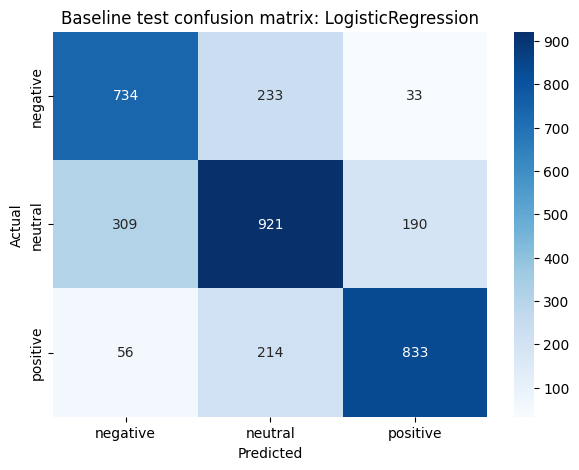

In [ ]:
baseline_test_predictions = best_baseline.predict(X_test)
print(classification_report(test_labels, baseline_test_predictions, target_names=label_encoder.classes_, zero_division=0))
baseline_test_metrics = {
    'accuracy': accuracy_score(test_labels, baseline_test_predictions),
    'precision': precision_score(test_labels, baseline_test_predictions, average='macro', zero_division=0),
    'recall': recall_score(test_labels, baseline_test_predictions, average='macro', zero_division=0),
    'f1': f1_score(test_labels, baseline_test_predictions, average='macro'),
}
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(test_labels, baseline_test_predictions), annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Baseline test confusion matrix: {best_baseline_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 6. Deep Learning Model: Fine-tuned Transformer
DistilBERT is fine-tuned on minimally cleaned text because its tokenizer and pretrained language representation can use punctuation and context. `bert-base-uncased` is a higher-capacity alternative when GPU resources allow it. To keep runtime practical, datasets larger than `MAX_SAMPLES` are sampled reproducibly.

In [ ]:
if len(train_df) > MAX_SAMPLES:
    print(f'Training data has {len(train_df)} rows; sampling MAX_SAMPLES={MAX_SAMPLES} for runtime control.')
    transformer_train = train_df.sample(MAX_SAMPLES, random_state=SEED).reset_index(drop=True)
else:
    transformer_train = train_df.copy()
transformer_val = val_df.copy()
transformer_test = test_df.copy()

tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL_NAME)


def to_dataset(frame):
    return Dataset.from_pandas(frame[['raw_text', 'label_id']].rename(columns={'label_id': 'labels'}), preserve_index=False)


hf_train = to_dataset(transformer_train)
hf_val = to_dataset(transformer_val)
hf_test = to_dataset(transformer_test)


def tokenize_batch(batch):
    return tokenizer(batch['raw_text'], truncation=True, max_length=256)


hf_train = hf_train.map(tokenize_batch, batched=True, remove_columns=['raw_text'])
hf_val = hf_val.map(tokenize_batch, batched=True, remove_columns=['raw_text'])
hf_test = hf_test.map(tokenize_batch, batched=True, remove_columns=['raw_text'])
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
model = AutoModelForSequenceClassification.from_pretrained(TRANSFORMER_MODEL_NAME, num_labels=len(label_encoder.classes_), id2label=label_mapping, label2id={label: index for index, label in label_mapping.items()})
accuracy_metric = evaluate.load('accuracy')
f1_metric = evaluate.load('f1')

Training data has 23295 rows; sampling MAX_SAMPLES=20000 for runtime control.


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4112 [00:00<?, ? examples/s]

Map:   0%|          | 0/3523 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


The tokenizer and Hugging Face datasets are ready. The next cell configures the Trainer with reproducible hyperparameters and starts fine-tuning, using smaller CPU settings when needed.

In [ ]:
def compute_metrics(eval_prediction):
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_metric.compute(predictions=predictions, references=labels)['accuracy'],
        'macro_f1': f1_metric.compute(predictions=predictions, references=labels, average='macro')['f1'],
    }

if not torch.cuda.is_available():
    print('WARNING: No GPU detected. Transformer training will be slower; Google Colab is recommended for faster runs.')
training_args = TrainingArguments(
    output_dir='sentiment_transformer_output',
    num_train_epochs=TRANSFORMER_EPOCHS,
    per_device_train_batch_size=TRANSFORMER_BATCH_SIZE,
    per_device_eval_batch_size=TRANSFORMER_BATCH_SIZE,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='no',
    logging_strategy='epoch',
    report_to='none',
    seed=SEED,
    data_seed=SEED,
)
trainer = Trainer(model=model, args=training_args, train_dataset=hf_train, eval_dataset=hf_val, data_collator=data_collator, compute_metrics=compute_metrics)
transformer_start = time.perf_counter()
trainer.train()
transformer_training_seconds = time.perf_counter() - transformer_start

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.606614,0.525731,0.783317,0.787018
2,0.429844,0.536296,0.791586,0.795262


Training has finished and the validation metric function was used during fitting. This cell performs the final transformer test evaluation and plots its confusion matrix.

              precision    recall  f1-score   support

    negative       0.77      0.79      0.78      1000
     neutral       0.75      0.77      0.76      1420
    positive       0.87      0.81      0.84      1103

    accuracy                           0.79      3523
   macro avg       0.80      0.79      0.79      3523
weighted avg       0.79      0.79      0.79      3523



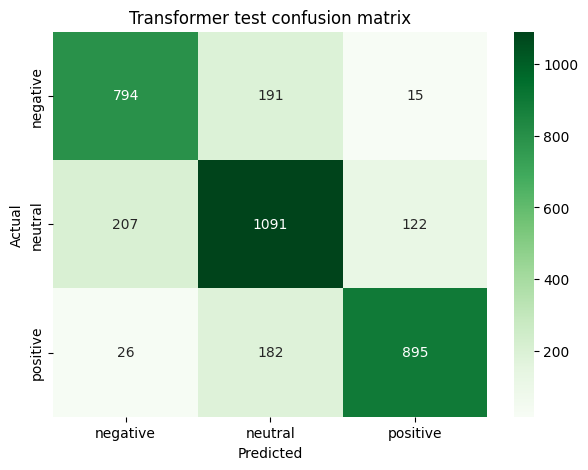

In [ ]:
transformer_output = trainer.predict(hf_test)
transformer_test_predictions = np.argmax(transformer_output.predictions, axis=-1)
transformer_test_labels = transformer_output.label_ids
print(classification_report(transformer_test_labels, transformer_test_predictions, target_names=label_encoder.classes_, zero_division=0))
transformer_test_metrics = {
    'accuracy': accuracy_score(transformer_test_labels, transformer_test_predictions),
    'precision': precision_score(transformer_test_labels, transformer_test_predictions, average='macro', zero_division=0),
    'recall': recall_score(transformer_test_labels, transformer_test_predictions, average='macro', zero_division=0),
    'f1': f1_score(transformer_test_labels, transformer_test_predictions, average='macro'),
}
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(transformer_test_labels, transformer_test_predictions), annot=True, fmt='d', cmap='Greens', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Transformer test confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 7. Model Comparison
The summary combines the same test metrics for both approaches. Accuracy is included for readability, while macro precision, recall, and F1 reveal how evenly the models handle all classes.

,model,accuracy,precision,recall,macro_f1,training_seconds
0,baseline,0.706,0.710,0.713,0.711,3.8
1,transformer,0.789,0.795,0.791,0.793,190.4


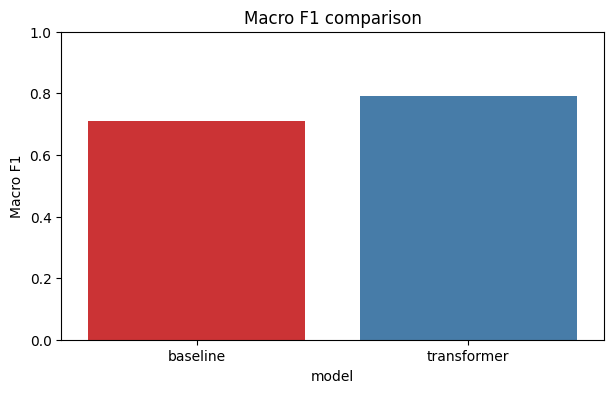

Better test macro F1: transformer


In [ ]:
comparison = pd.DataFrame([
    {'model': 'baseline', **baseline_test_metrics, 'training_seconds': baseline_validation.loc[baseline_validation['model'] == best_baseline_name, 'training_seconds'].iloc[0]},
    {'model': 'transformer', **transformer_test_metrics, 'training_seconds': transformer_training_seconds},
]).rename(columns={'f1': 'macro_f1'})
display(comparison.style.format({'accuracy': '{:.3f}', 'precision': '{:.3f}', 'recall': '{:.3f}', 'macro_f1': '{:.3f}', 'training_seconds': '{:.1f}'}))
plt.figure(figsize=(7, 4))
sns.barplot(data=comparison, x='model', y='macro_f1', palette='Set1')
plt.ylim(0, 1)
plt.title('Macro F1 comparison')
plt.ylabel('Macro F1')
plt.show()
better_model = comparison.sort_values('macro_f1', ascending=False).iloc[0]['model']
print(f'Better test macro F1: {better_model}')

The transformer may achieve stronger results because it uses contextual representations, but it requires considerably more compute and is slower to train. The TF-IDF baseline is easier to interpret, faster to retrain, and often competitive on short, domain-specific text. The test scores above determine which model is better for this particular dataset.

## 8. Error Analysis
Inspecting mistakes turns a score into an explanation. We display up to ten examples from the better-performing model so patterns such as sarcasm, mixed sentiment, ambiguity, or very short messages can be discussed honestly.

In [ ]:
if better_model == 'transformer':
    error_frame = transformer_test[['raw_text', 'normalized_label']].copy().reset_index(drop=True)
    error_frame['actual'] = transformer_test_labels
    error_frame['predicted'] = transformer_test_predictions
else:
    error_frame = test_df[[TEXT_COLUMN, 'normalized_label']].copy().reset_index(drop=True)
    error_frame['raw_text'] = error_frame[TEXT_COLUMN]
    error_frame['actual'] = test_labels
    error_frame['predicted'] = baseline_test_predictions
error_frame['actual_label'] = error_frame['actual'].map(label_mapping)
error_frame['predicted_label'] = error_frame['predicted'].map(label_mapping)
errors = error_frame[error_frame['actual'] != error_frame['predicted']]
display(errors[['raw_text', 'actual_label', 'predicted_label']].head(10))
print('Common patterns to consider: sarcasm and figurative language, mixed positive/negative wording, limited context, misspellings, and short neutral statements.')

,raw_text,actual_label,predicted_label
9,What did you get? My day is alright.. haven`t...,neutral,positive
19,"I`m going into a spiritual stagnentation, its ...",neutral,negative
21,My dead grandpa pays more attention to me than...,negative,neutral
26,"hey peoples, dont you just hate being grounded...",neutral,negative
28,look who I found just for you --->,positive,neutral
37,So I really need to put the laptop down & star...,neutral,negative
40,4n? ma rog never heard of it esti beat acum?...,negative,neutral
41,I always forget SOMETHING when I travel. I am ...,neutral,negative
56,U so dirrrrrty... Why oh why did I pick the Ha...,neutral,positive
57,almost got a kitty yesterday...but it didn`t w...,neutral,negative


Common patterns to consider: sarcasm and figurative language, mixed positive/negative wording, limited context, misspellings, and short neutral statements.


## 9. Inference Function
A single prediction function makes the trained artifacts reusable. It returns the original text, the predicted class, and a probability-based confidence estimate for either model choice.

In [ ]:
def predict_sentiment(text: str, model_choice: str = 'transformer') -> dict:
    """Return {'text': ..., 'sentiment': ..., 'confidence': float}."""
    if not isinstance(text, str) or not text.strip():
        raise ValueError('text must be a non-empty string.')
    if model_choice not in {'baseline', 'transformer'}:
        raise ValueError("model_choice must be 'baseline' or 'transformer'.")
    if model_choice == 'baseline':
        features = vectorizer.transform([clean_text(text)])
        predicted_id = int(best_baseline.predict(features)[0])
        if hasattr(best_baseline, 'predict_proba'):
            confidence = float(np.max(best_baseline.predict_proba(features)))
        else:
            decision = best_baseline.decision_function(features)
            confidence = float(1 / (1 + np.exp(-np.max(np.atleast_1d(decision)))))
    else:
        inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=256)
        inputs = {key: value.to(trainer.model.device) for key, value in inputs.items()}
        with torch.no_grad():
            logits = trainer.model(**inputs).logits
        probabilities = torch.softmax(logits, dim=-1)[0]
        predicted_id = int(torch.argmax(probabilities).item())
        confidence = float(probabilities[predicted_id].item())
    return {'text': text, 'sentiment': label_mapping[predicted_id], 'confidence': round(confidence, 4)}

custom_examples = [
    'I am delighted that the package arrived early.',
    'The support team ignored my issue for three days.',
    'It was okay, nothing memorable.',
    'Fantastic, another update that breaks everything.',
    'I expected better, but the ending was surprisingly moving.',
    'I hate everyone'
]
for example in custom_examples:
    print(predict_sentiment(example, model_choice=better_model))

{'text': 'I am delighted that the package arrived early.', 'sentiment': 'positive', 'confidence': 0.9823}
{'text': 'The support team ignored my issue for three days.', 'sentiment': 'neutral', 'confidence': 0.5314}
{'text': 'It was okay, nothing memorable.', 'sentiment': 'neutral', 'confidence': 0.6222}
{'text': 'Fantastic, another update that breaks everything.', 'sentiment': 'positive', 'confidence': 0.8359}
{'text': 'I expected better, but the ending was surprisingly moving.', 'sentiment': 'positive', 'confidence': 0.7382}
{'text': 'I hate everyone', 'sentiment': 'negative', 'confidence': 0.9818}
